## Visualization Using Dimensionality Reduction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

In [2]:
# Recreating the transformed dataset as created in '04-data-transformation.ipynb'

amazon1 = pd.read_csv('/workspaces/group-project-bas-team/data/AmazonData1.csv')
amazon2 = pd.read_csv('/workspaces/group-project-bas-team/data/AmazonData2.csv')
amazon_data = [amazon1, amazon2]
amazon = pd.concat(amazon_data)

survey = pd.read_csv('/workspaces/group-project-bas-team/data/survey.csv')
survey = survey.sample(1000, random_state=42)

data = pd.merge(amazon, survey, on='Survey ResponseID', how='inner')

codes = data[['ASIN/ISBN (Product Code)', 'Title']].drop_duplicates().dropna()
codes_dict = codes.set_index('ASIN/ISBN (Product Code)')['Title'].to_dict()
data['Title'] = data['ASIN/ISBN (Product Code)'].map(codes_dict)

cats = data[['ASIN/ISBN (Product Code)', 'Category']].drop_duplicates().dropna()
cats_dict = cats.set_index('ASIN/ISBN (Product Code)')['Category'].to_dict()
data['Category'] = data['ASIN/ISBN (Product Code)'].map(cats_dict)

data['Q-life-changes'] = data['Q-life-changes'].fillna('None')

data = data.dropna()

data.columns = data.columns.str.replace('Q-', '')\
    .str.replace('demos-', '')\
    .str.replace('amazon-use-', '')\
    .str.replace('substance-use-', '')\
    .str.replace('personal-', '')

data = data.reset_index()
data = data.drop('index', axis=1)

data[['order_month', 'order_day', 'order_year']] = data['Order Date'].str.split('/', expand=True)
data = data.drop('Order Date', axis=1)
data[['order_month', 'order_day', 'order_year']] = data[['order_month', 'order_day', 'order_year']].apply(pd.to_numeric)

cols_to_drop = [
    'Survey ResponseID',
    'sell-YOUR-data',
    'sell-consumer-data',
    'small-biz-use',
    'census-use',
    'research-society'
]

data = data.drop(columns=cols_to_drop)

ordinal_mappings = {
    'age': {
        '18 - 24 years': 1,
        '25 - 34 years': 2,
        '35 - 44 years': 3,
        '45 - 54 years': 4,
        '55 - 64 years': 5,
        '65 and older': 6
    },
    'education': {
        'Prefer not to say': 0,
        'Some high school or less': 1,
        'High school diploma or GED': 2,
        "Bachelor's degree": 3,
        'Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS, etc)': 4
    },
    'income': {
        'Prefer not to say': 0,
        'Less than $25,000': 1,
        '$25,000 - $49,999': 2,
        '$50,000 - $74,999': 3,
        '$75,000 - $99,999': 4,
        '$100,000 - $149,999': 5,
        '$150,000 or more': 6
    },
    'howmany': {
        '1 (just me!)': 1,
        '2': 2,
        '3': 3,
        '4+': 4
    },
    'hh-size': {
        '1 (just me!)': 1,
        '2': 2,
        '3': 3,
        '4+': 4
    },
    'how-oft': {
        'Less than 5 times per month': 1,
        '5 - 10 times per month': 2,
        'More than 10 times per month': 3
    }
}
for col, mapping in ordinal_mappings.items():
    data[col] = data[col].map(mapping)

yes_no_map = {'Yes': 1, 'No': 0}

data['hispanic'] = data['hispanic'].map(yes_no_map)

encoder = OneHotEncoder(sparse_output=False)

data_one_hot = encoder.fit_transform(data[['cigarettes', 'alcohol', 'marijuana', 'diabetes',\
                                            'wheelchair', 'Shipping Address State', 'gender',\
                                            'sexual-orientation', 'state', 'race', 'life-changes']])
df_one_hot = pd.DataFrame(data_one_hot, columns=encoder\
                          .get_feature_names_out(['cigarettes', 'alcohol', 'marijuana', 'diabetes',\
                                                    'wheelchair', 'Shipping Address State', 'gender',\
                                                    'sexual-orientation', 'state', 'race', 'life-changes']))

df_one_hot = df_one_hot.drop(columns=['cigarettes_Prefer not to say', 'alcohol_Prefer not to say', \
                                      'marijuana_Prefer not to say', 'diabetes_Prefer not to say', \
                                        'wheelchair_Prefer not to say', 'Shipping Address State_HI', \
                                        'gender_Prefer not to say', 'sexual-orientation_prefer not to say', \
                                        'state_Alaska', 'race_Other', 'life-changes_None'])

df_combined = pd.concat([data, df_one_hot], axis=1)
df_combined = df_combined.drop(columns=['cigarettes', 'alcohol', 'marijuana', 'diabetes',\
                                            'wheelchair', 'Shipping Address State', 'gender',\
                                            'sexual-orientation', 'state', 'race', 'life-changes'])

le = LabelEncoder()

target_cols = ['Title', 'ASIN/ISBN (Product Code)', 'Category']

for col in target_cols:
    df_combined[col] = le.fit_transform(df_combined[col].astype(str))

df_combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 192556 entries, 0 to 192555
Columns: 159 entries, Purchase Price Per Unit to life-changes_Moved place of residence,Had a child
dtypes: float64(145), int64(14)
memory usage: 233.6 MB


In [3]:
# to start, we will try using Category as our target
# this best simulates our end goal of enhancing product recommendation
# we are hoping to be able to use demographics and previous purchases to identify what products to recommend
# Since title and ASIN/ISBN directly determine the category, we will create a subset of the data that does not include these features
data_limited = df_combined.drop(['Title', 'ASIN/ISBN (Product Code)'], axis=1)

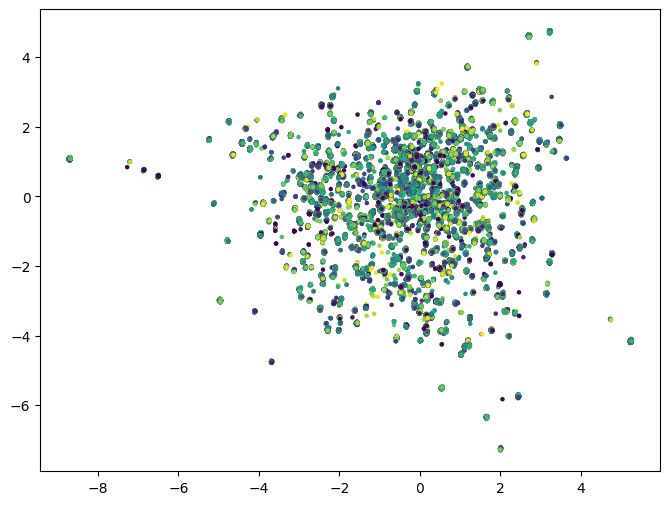

In [4]:
# NEED TO ENCODE NON-NUMERIC VARIABLES BEFORE RUNNING

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = data_limited.drop('Category', axis=1)
y = data_limited['Category']
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#We'll need to figure out what plots to use as well as what specific columns we want to target

#Gets visualization plot started
plt.figure(figsize=(8, 6))
#Insert plot of choice here
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=5)
plt.show()